Loaded 28 halos: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]
Halos successfully interpolated: 28

Fit results:
  Power-law:   ratio = 0.9728 * t^-0.0482
  Linear:      ratio = -0.0356 * t + 1.0339
  Exponential: ratio = 1.0358 * exp(-0.0373 * t)


/tmp/ipykernel_1040041/32999228.py:86: RuntimeWarning: Mean of empty slice
  mean_ratio = np.nanmean(ratio_matrix, axis=0)
/astro/users/shriyp/.local/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_1040041/32999228.py:188: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


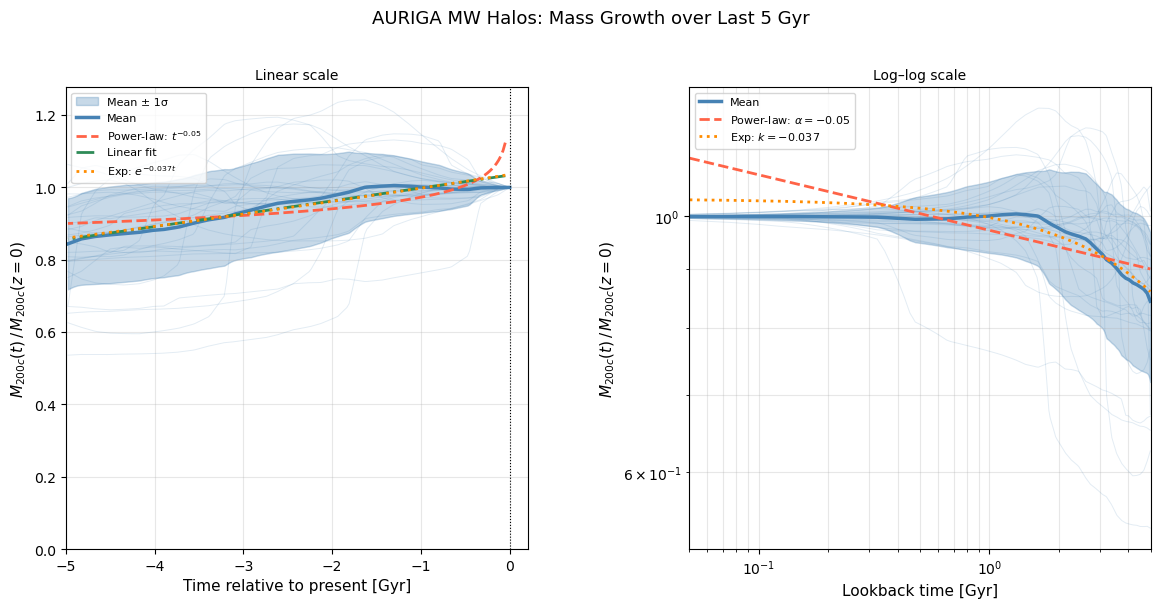

In [1]:
"""
AURIGA MW Halo Mass Growth Analysis
Plots M200c / M200c(z=0) as a function of lookback time over the last 5 Gyr.
Interpolates each halo onto a common time grid, computes mean ± std,
and fits various scaling relations on log-log scale.
"""

import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from astropy.cosmology import WMAP9
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

# ── Config ──────────────────────────────────────────────────────────────────
AURIGA_DIR = '/astro/store/shire/stream_team/auriga_props'
MASS_PROPS_DIR = Path(AURIGA_DIR) / "AURIGA_MW_m200.pkl"

T_MIN, T_MAX = 0.0, 5.0          # Gyr lookback time window
N_GRID       = 200                # interpolation grid points
DECIMALS     = 3                  # for np.around on lookback times

# ── Load data ────────────────────────────────────────────────────────────────
with open(MASS_PROPS_DIR, "rb") as f:
    mass_props = pickle.load(f)

# -- Remove these keys -----------------------------------
mass_props.pop(1, None); mass_props.pop(11, None)

halo_ids = list(mass_props.keys())
print(f"Loaded {len(halo_ids)} halos: {halo_ids}")

# ── Common interpolation grid (linear spacing, 0 → 5 Gyr lookback) ──────────
t_grid = np.linspace(T_MIN, T_MAX, N_GRID)   # lookback time [Gyr]

# ── Interpolate each halo ────────────────────────────────────────────────────
ratio_matrix = []   # shape: (n_halos, N_GRID)

for hid in halo_ids:
    z    = mass_props[hid]["redshift"]
    m200 = mass_props[hid]["m200c"]

    # lookback time for each snapshot, rounded like the user wants
    t_lb = np.around(WMAP9.lookback_time(z).value, decimals=DECIMALS)

    # sort by increasing lookback time (ascending z)
    order = np.argsort(t_lb)
    t_lb  = t_lb[order]
    m200  = m200[order]

    # present-day mass = value at smallest lookback time (z~0)
    # use the snapshot closest to t=0
    idx_z0 = np.argmin(t_lb)
    m200_z0 = m200[idx_z0]

    if m200_z0 <= 0:
        print(f"  Halo {hid}: m200 at z=0 is non-positive, skipping.")
        continue

    ratio = m200 / m200_z0

    # keep only the 0–5 Gyr window (require at least a few points)
    mask = (t_lb >= T_MIN) & (t_lb <= T_MAX)
    if mask.sum() < 3:
        print(f"  Halo {hid}: too few snapshots in 0–5 Gyr window, skipping.")
        continue

    t_use = t_lb[mask]
    r_use = ratio[mask]

    # ensure unique t values for interpolation
    _, uniq = np.unique(t_use, return_index=True)
    t_use, r_use = t_use[uniq], r_use[uniq]

    # interpolate onto common grid (linear, no extrapolation)
    f_interp = interp1d(t_use, r_use, kind="linear",
                        bounds_error=False, fill_value=np.nan)
    ratio_matrix.append(f_interp(t_grid))

ratio_matrix = np.array(ratio_matrix)   # (n_halos, N_GRID)
print(f"Halos successfully interpolated: {ratio_matrix.shape[0]}")

# ── Statistics (ignore NaNs) ─────────────────────────────────────────────────
mean_ratio = np.nanmean(ratio_matrix, axis=0)
std_ratio  = np.nanstd(ratio_matrix,  axis=0)

# ── Fitting (exclude t=0 to avoid log issues) ────────────────────────────────
fit_mask = (t_grid > 0.05) & np.isfinite(mean_ratio) & (mean_ratio > 0)
t_fit  = t_grid[fit_mask]
r_fit  = mean_ratio[fit_mask]

log_t = np.log10(t_fit)
log_r = np.log10(r_fit)

# 1) Power-law: ratio = a * t^b  →  log(ratio) = log(a) + b*log(t)
coeffs_pl = np.polyfit(log_t, log_r, 1)
b_pl, log_a_pl = coeffs_pl
a_pl = 10**log_a_pl

# 2) Linear in linear space: ratio = c * t + d
coeffs_lin = np.polyfit(t_fit, r_fit, 1)
c_lin, d_lin = coeffs_lin

# 3) Exponential: ratio = A * exp(k * t)
def exp_model(t, A, k):
    return A * np.exp(k * t)

try:
    popt_exp, _ = curve_fit(exp_model, t_fit, r_fit, p0=[0.8, 0.05])
    A_exp, k_exp = popt_exp
    exp_ok = True
except Exception:
    exp_ok = False

print(f"\nFit results:")
print(f"  Power-law:   ratio = {a_pl:.4f} * t^{b_pl:.4f}")
print(f"  Linear:      ratio = {c_lin:.4f} * t + {d_lin:.4f}")
if exp_ok:
    print(f"  Exponential: ratio = {A_exp:.4f} * exp({k_exp:.4f} * t)")

# ── Plotting ─────────────────────────────────────────────────────────────────
# Convert lookback time → signed time (negative = past, 0 = present)
t_signed = -t_grid    # e.g. -5 to 0

fig = plt.figure(figsize=(14, 6))
fig.suptitle("AURIGA MW Halos: Mass Growth over Last 5 Gyr", fontsize=13, y=1.01)
gs = gridspec.GridSpec(1, 2, wspace=0.35)

# ── Left panel: linear scale ─────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])

for row in ratio_matrix:
    ax1.plot(t_signed, row, color="steelblue", alpha=0.15, lw=0.7)

ax1.fill_between(t_signed, mean_ratio - std_ratio, mean_ratio + std_ratio,
                 color="steelblue", alpha=0.3, label="Mean ± 1σ")
ax1.plot(t_signed, mean_ratio, color="steelblue", lw=2.5, label="Mean")

# overlay fits
t_fit_signed = -t_fit
ax1.plot(t_fit_signed, a_pl * t_fit**b_pl,     color="tomato",   lw=2,
         ls="--", label=f"Power-law: $t^{{{b_pl:.2f}}}$")
ax1.plot(t_fit_signed, c_lin * t_fit + d_lin,  color="seagreen", lw=2,
         ls="-.", label=f"Linear fit")
if exp_ok:
    ax1.plot(t_fit_signed, exp_model(t_fit, A_exp, k_exp), color="darkorange",
             lw=2, ls=":", label=f"Exp: $e^{{{k_exp:.3f}t}}$")

ax1.axvline(0, color="k", lw=0.8, ls=":")
ax1.set_xlabel("Time relative to present [Gyr]", fontsize=11)
ax1.set_ylabel(r"$M_{200c}(t)\,/\,M_{200c}(z=0)$", fontsize=11)
ax1.set_title("Linear scale", fontsize=10)
ax1.set_xlim(-T_MAX, 0.2)
ax1.set_ylim(bottom=0)
ax1.legend(fontsize=8, loc="upper left")
ax1.grid(True, alpha=0.3)

# ── Right panel: log-log ─────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])

# For log-log we plot vs positive lookback time (t=0 is present)
for row in ratio_matrix:
    ax2.loglog(t_grid[t_grid > 0], row[t_grid > 0],
               color="steelblue", alpha=0.15, lw=0.7)

ok = (t_grid > 0) & np.isfinite(mean_ratio) & (mean_ratio > 0)
ax2.fill_between(t_grid[ok],
                 (mean_ratio - std_ratio)[ok],
                 (mean_ratio + std_ratio)[ok],
                 color="steelblue", alpha=0.3)
ax2.loglog(t_grid[ok], mean_ratio[ok], color="steelblue", lw=2.5, label="Mean")

ax2.loglog(t_fit, a_pl * t_fit**b_pl, color="tomato", lw=2, ls="--",
           label=f"Power-law: $\\alpha={b_pl:.2f}$")
if exp_ok:
    ax2.loglog(t_fit, exp_model(t_fit, A_exp, k_exp), color="darkorange",
               lw=2, ls=":", label=f"Exp: $k={k_exp:.3f}$")

ax2.set_xlabel("Lookback time [Gyr]", fontsize=11)
ax2.set_ylabel(r"$M_{200c}(t)\,/\,M_{200c}(z=0)$", fontsize=11)
ax2.set_title("Log–log scale", fontsize=10)
ax2.set_xlim(0.05, T_MAX)
ax2.legend(fontsize=8)
ax2.grid(True, which="both", alpha=0.3)

plt.tight_layout()
# plt.savefig("/mnt/user-data/outputs/auriga_mass_growth.pdf", bbox_inches="tight", dpi=150)
# plt.savefig("/mnt/user-data/outputs/auriga_mass_growth.png", bbox_inches="tight", dpi=150)
# plt.show()
# print("\nSaved: auriga_mass_growth.pdf / .png")

In [2]:
import os, sys, pickle, numpy as np
from pathlib import Path

sys.path.insert(1, '/astro/users/arora125/libs')
import compute_characteristics_ut as cc

import importlib
importlib.reload(cc)

from tqdm import tqdm, trange

import agama
agama.setUnits(mass=1, length=1, velocity=1)


import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.colors import SymLogNorm, LogNorm
import cmasher as cmr
%matplotlib inline

In [3]:
AURIGA_DIR = '/astro/store/shire/stream_team/auriga_props'

In [7]:
MASS_PROPS_DIR = Path(AURIGA_DIR) / 'AURIGA_MW_m200.pkl'
with open(MASS_PROPS_DIR, 'rb') as f:
    mass_props = pickle.load(f)
mass_props.pop(1, None); mass_props.pop(11, None)
# # Lookback time from astropy cosmology:
from astropy.cosmology import WMAP9



In [8]:
WMAP9.lookback_time(8.4)

<Quantity 13.16203274 Gyr>

In [9]:
mass_props[1]['m200c']

KeyError: 1

In [10]:
len(mass_props[11]['m200c'])

KeyError: 11

In [11]:
_lvl = 3
_halo_num = 23
_nsnap = 55
POT_PATH = Path(AURIGA_DIR) / 'potentials' / f'potential_level{_lvl}_halo{_halo_num}_snap{_nsnap}_dm'

In [12]:
pot_model = agama.Potential(file=POT_PATH)

rmax = 22.638298339394368
vmax = 201.97288352308277
NFW rs = 10.466157345998322


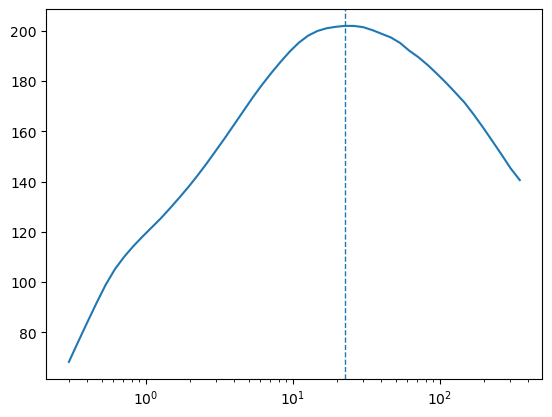

In [13]:
radius = np.logspace(np.log10(0.3), np.log10(350), 50)
mass_enc = pot_model.enclosedMass(radius)*2

G = 4.30091e-6

vcirc = np.sqrt(G * mass_enc / radius)

imax = np.argmax(vcirc)
rmax = radius[imax]
vmax = vcirc[imax]

rs = rmax / 2.163

print("rmax =", rmax)
print("vmax =", vmax)
print("NFW rs =", rs)
plt.semilogx(radius, vcirc)
plt.axvline(rmax, lw=1, ls='--')

In [16]:
print(mass_enc)

mass_enc.shape

[3.24208537e+08 4.66733088e+08 6.55536358e+08 9.01755950e+08
 1.21439154e+09 1.58341624e+09 2.00354167e+09 2.49642464e+09
 3.08012968e+09 3.78065242e+09 4.63324780e+09 5.70070432e+09
 7.01480600e+09 8.63445842e+09 1.06498966e+10 1.31522731e+10
 1.62626615e+10 2.00722409e+10 2.47798330e+10 3.05278532e+10
 3.75363418e+10 4.58696847e+10 5.57967624e+10 6.75701226e+10
 8.15116442e+10 9.76861496e+10 1.16049330e+11 1.36541549e+11
 1.59443240e+11 1.85216744e+11 2.14718545e+11 2.47961430e+11
 2.84946616e+11 3.25262230e+11 3.70226918e+11 4.21408144e+11
 4.75925461e+11 5.32439693e+11 5.98476307e+11 6.68716938e+11
 7.44060628e+11 8.25579541e+11 9.12758764e+11 1.00691703e+12
 1.09910411e+12 1.19324392e+12 1.28872881e+12 1.38769644e+12
 1.48678336e+12 1.60782589e+12]


(50,)